In [1]:
import torch

print(f"PyTorch 버전: {torch.__version__}")
print(f"CUDA 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU 이름: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA를 사용할 수 없습니다.")

PyTorch 버전: 2.5.1+cu118
CUDA 사용 가능 여부: True
GPU 이름: NVIDIA GeForce RTX 4060 Ti


### PER 분석

In [2]:
# 1. 라이브러리 임포트
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# 1. 라이브러리 임포트
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. 데이터 불러오기
df = pd.read_csv("C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_advanced_stats.csv")

# 3. 컬럼명 통일
df = df.rename(columns={'PLAYER': 'PLAYER_NAME', 'POS': 'POSITION'})

# 4. 결측치 처리
# PER 또는 POSITION에 결측치가 있는 행 제거
df = df.dropna(subset=['PER', 'POSITION'])

# 5. 이상치(Outlier) 제거 — IQR 방법 적용
Q1 = df['PER'].quantile(0.25)
Q3 = df['PER'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df['PER'] >= lower_bound) & (df['PER'] <= upper_bound)]

In [16]:

# 6. 정제된 데이터 저장
df.to_csv('C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_PER_rate.csv', index=False)
print("Cleaned data saved to CSV.")

Cleaned data saved to CSV.


In [3]:
# 7. 상위 10명 PER 출력
global_top10 = df[['PLAYER_NAME', 'PER']].sort_values(by='PER', ascending=False)
print("Top 10 Players by PER (after cleaning):")
print(global_top10.head(10).to_string(index=False))

# 8. 포지션별 평균 PER 계산
avg_per_position = df.groupby('POSITION')['PER'].mean().reset_index()
print("\nAverage PER by Position (after cleaning):")
print(avg_per_position.to_string(index=False))

Top 10 Players by PER (after cleaning):
         PLAYER_NAME  PER
        Jimmy Butler 22.2
       Stephen Curry 21.5
Trayce Jackson-Davis 18.5
          Kevin Knox 17.1
        Kevon Looney 17.0
      Andrew Wiggins 16.4
      Gary Payton II 16.2
        Jackson Rowe 15.9
    Jonathan Kuminga 15.7
       Kyle Anderson 14.8

Average PER by Position (after cleaning):
POSITION       PER
       C 17.750000
      PF 14.116667
      PG 16.000000
      SF 18.566667
      SG 12.200000


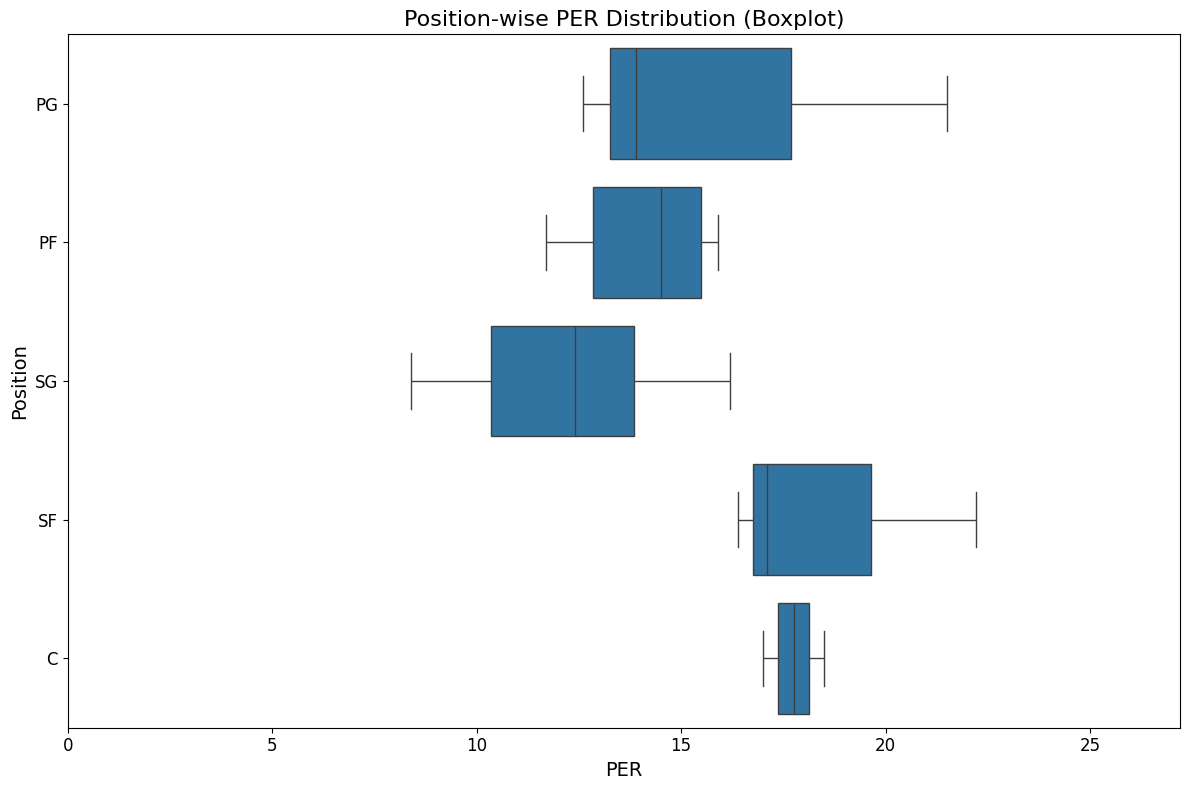

In [18]:
# 8. 시각화 — Boxplot (일반 가로형)
plt.figure(figsize=(12, 8))
sns.boxplot(y='POSITION', x='PER', data=df)
plt.title('Position-wise PER Distribution (Boxplot)', fontsize=16)
plt.xlabel('PER', fontsize=14)
plt.ylabel('Position', fontsize=14)
plt.xlim(0, df['PER'].max() + 5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


In [5]:
# 12. 팀 전체 PER 계산
# (1) 단순 평균 PER
team_per_simple = df['PER'].mean()
print(f"Team PER (simple average): {team_per_simple:.2f}")
# (2) 가중 평균 PER (플레이시간 기준)
if 'MP' in df.columns:
    team_per_weighted = (df['PER'] * df['MP']).sum() / df['MP'].sum()
    print(f"Team PER (weighted by minutes): {team_per_weighted:.2f}")
else:
    print("Minutes played ('MP') column not found; weighted PER cannot be calculated.")


Team PER (simple average): 14.73
Team PER (weighted by minutes): 15.17


C:\Users\THKIM\AppData\Local\Temp\ipykernel_2460\2363881847.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PER', y='PLAYER_NAME', data=top_players, palette='viridis')


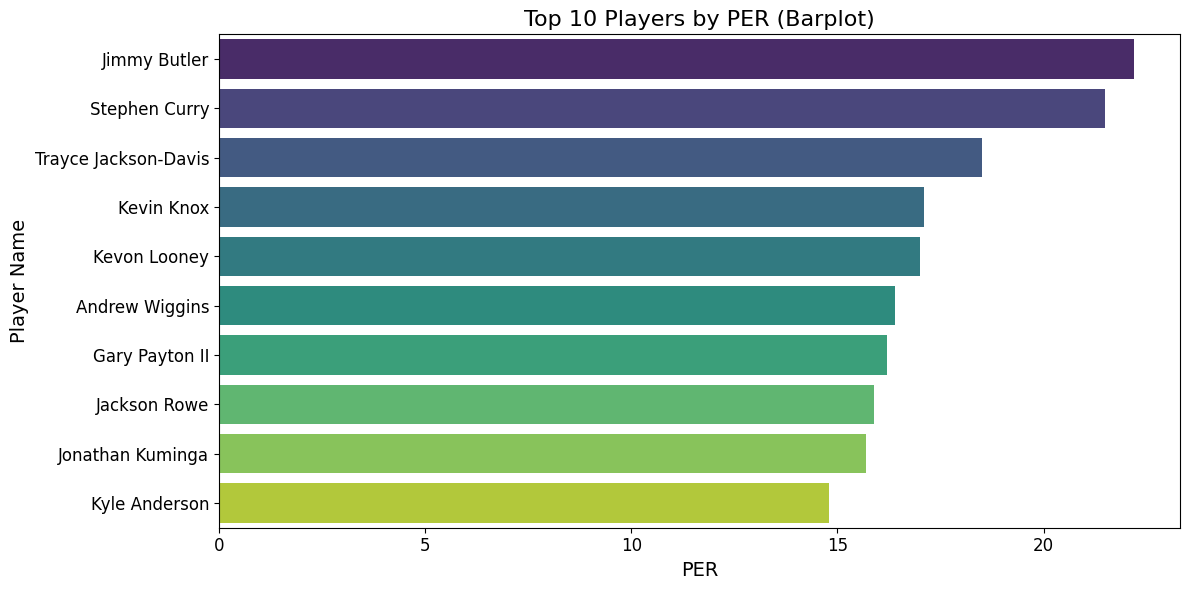

In [6]:
# 13. 선수별 PER 시각화 — 상위 10명 Barplot
top_players = df.sort_values(by='PER', ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x='PER', y='PLAYER_NAME', data=top_players, palette='viridis')
plt.title('Top 10 Players by PER (Barplot)', fontsize=16)
plt.xlabel('PER', fontsize=14)
plt.ylabel('Player Name', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


시각화 분석
PER 값은 선수가 한 경기당 얼마나 효율적으로 기여했는지 볼 수 있는 지표입니다. 
PER 값은 긍정기여(득점,리바운드,어시스트,스틸,블록 등)값 - 부정기여(야투,자유투실패,턴오버,파울)를 한다음, 1분당 단위로 환산하고 가중치를 조정한 다음 합산한 값입니다. 
리그 전체 평균은 PER은 15로 고정되며, 15를 넘어선다면 평균 이하, 15를 넘어서지 않으면 평균 이상의 효율성을 가지고 있다는 것을 알 수 있습니다. 

이 시각화 지표는 각 선수별의 PER값을 계산하여, 포지션별로 그룹화하여 박스플롯으로 나타낸 값입니다. 

mall Forward(SF):최고 생산성
SF의 중앙값이 가장 높아, 이 포지션에 배치된 선수들은 평균적으로 PER가 높습니다.
“3번” 자리에 다재다능한 득점·수비형 선수 비중을 늘리면 팀 효율을 극대화할 수 있죠.

Center(C) 안정적 기여
C는 분포 폭이 좁아, 누구를 쓰더라도 ‘기본 이상’의 생산성 보장
확실한 리바운드·인사이드 득점을 위해 로테이션 중심에 두기 적합

Point Guard(PG):편차 관리 필요
PG는 중앙값이 보통이지만, 효율성 편차가 큽니다.
“누구를 기용하느냐”에 따라 팀 퍼포먼스가 크게 달라지므로,
핵심 1번은 엄선하고
벤치엔 안정적인 백업을 두어 리스크를 분산하세요.

Shooting Guard(SG)와 Power Forward(PF)의 균형
두 포지션 모두 중간 정도의 PER 분포 폭을 보이므로
전략적 매치업, 역할 분담(슈팅·수비형 가드 vs. 스페이싱·픽롤 파워포워드)을 통해 시너지를 노려볼만 합니다.

In [12]:
# 1. 라이브러리 임포트
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. 스타일 설정
sns.set_style('whitegrid')  # 흰 배경 + 그리드
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
sns.despine(left=False, bottom=False)

# 3. CSV 파일로 GSW PER 데이터 불러오기
csv_path = "C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_PER.csv"  # Position 컬럼 포함된 파일
df = pd.read_csv(csv_path)

# 4. 컬럼명 통일 및 필수 컬럼 확인
df.rename(columns=lambda c: c.strip(), inplace=True)
for col in ['PLAYER_NAME', 'PER', 'POSITION']:
    if col not in df.columns:
        raise KeyError(f"필수 컬럼 '{col}'을(를) 찾을 수 없습니다. df.columns: {df.columns.tolist()}")

# 5. 상위 10 선수 및 포지션별 평균 계산
top10 = df[['PLAYER_NAME','PER','POSITION']].sort_values('PER', ascending=False).head(10)

# 6. 포지션별 색상 팔레트 정의
pos_palette = {
    'PG': '#1f77b4',  # 파란
    'SG': '#ff7f0e',  # 주황
    'SF': '#2ca02c',  # 초록
    'PF': '#d62728',  # 빨강
    'C':  '#9467bd'   # 보라
}


<Figure size 640x480 with 0 Axes>

Detected Outliers (PER):
PLAYER_NAME POSITION       PER
Braxton Key       SF  7.177360
Pat Spencer       SG 18.891843


C:\Users\THKIM\AppData\Local\Temp\ipykernel_21388\3189984050.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 640x480 with 0 Axes>

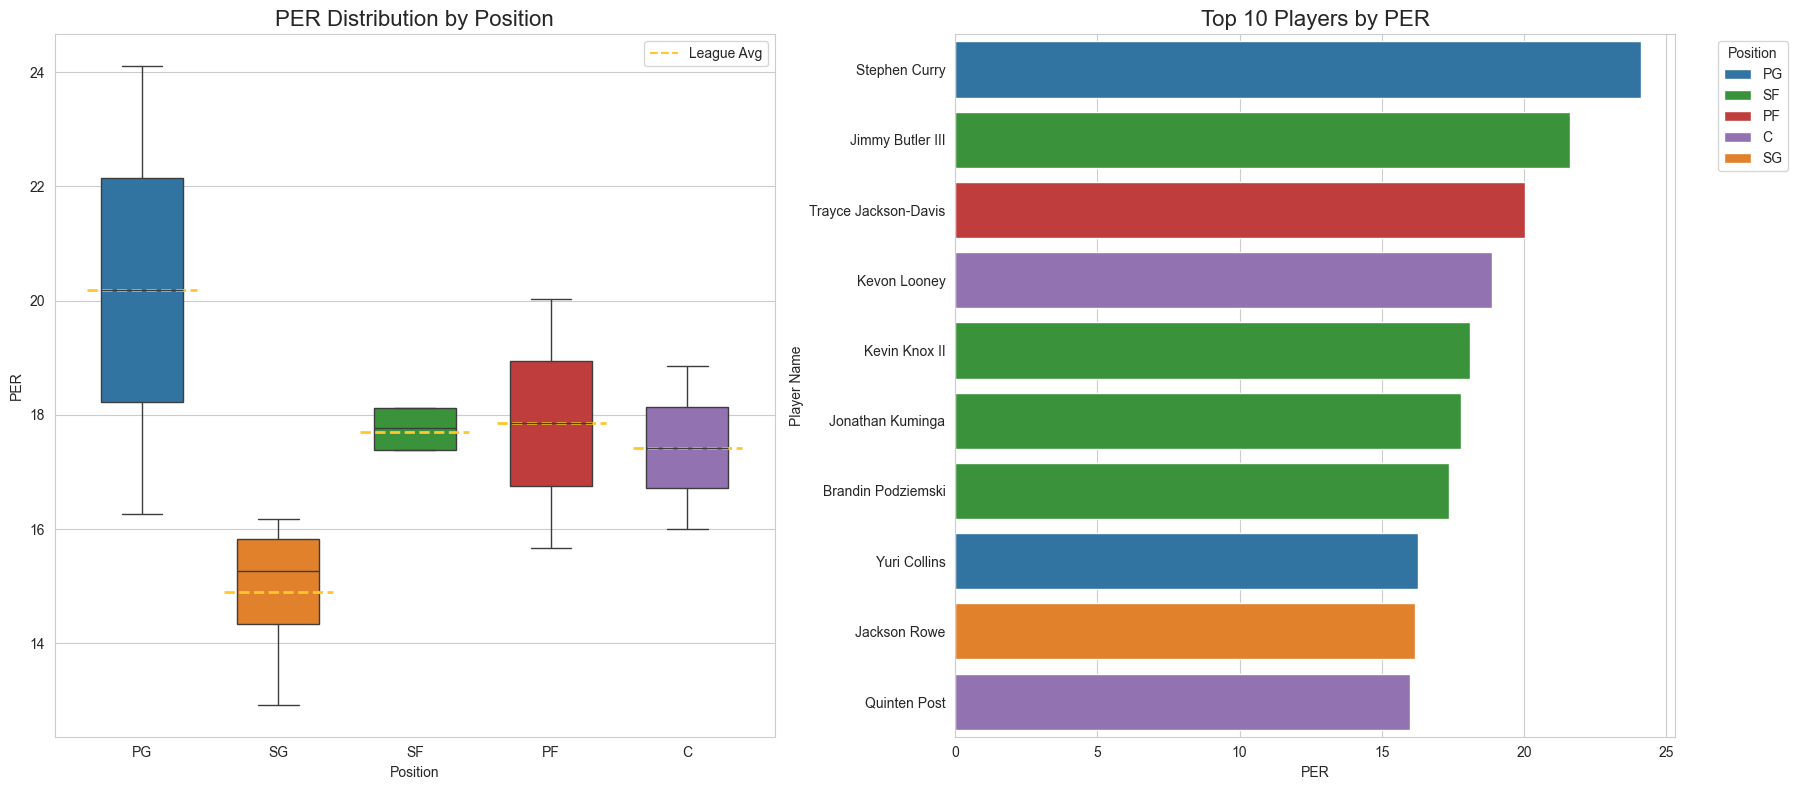

In [ ]:
# 1. 라이브러리 임포트
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 2. 스타일 설정
sns.set_style('whitegrid')  # 흰 배경 + 그리드
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
sns.despine(left=False, bottom=False)

# 3. CSV 파일로 GSW PER 데이터 불러오기
# 실제 PER 값이 담긴 파일 경로로 수정하세요
csv_path = "C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_PER.csv"
df = pd.read_csv(csv_path)

# 4. 결측치 제거 (PER 또는 POSITION이 없는 행 제거)
df.dropna(subset=['PER', 'POSITION'], inplace=True)

# Outlier 탐지 — IQR 방식으로 포지션별 이상치 식별 및 제거
outliers = []
for pos, group in df.groupby('POSITION'):
    Q1 = group['PER'].quantile(0.25)
    Q3 = group['PER'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask = (group['PER'] < lower) | (group['PER'] > upper)
    offs = group[mask][['PLAYER_NAME','POSITION','PER']]
    outliers.append(offs)
outliers_df = pd.concat(outliers)
print("Detected Outliers (PER):")
print(outliers_df.to_string(index=False))

# 이상치 제거: 박스플롯에서 보여지는 영향 완화 위해 outliers 제거
df = df[~df['PLAYER_NAME'].isin(outliers_df['PLAYER_NAME'])]  # 이상치 선수 제거(index=False))

# 5. 상위 10 선수 및 포지션별 평균 계산 및 포지션별 평균 계산
top10 = df.sort_values('PER', ascending=False).head(10)
avg_pos = df.groupby('POSITION')['PER'].mean().reset_index()

# 6. 포지션별 색상 정의
pos_palette = {
    'PG': '#1f77b4',
    'SG': '#ff7f0e',
    'SF': '#2ca02c',
    'PF': '#d62728',
    'C':  '#9467bd'
}

# 7. 시각화 — 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')
fig.subplots_adjust(wspace=0.5)

# 7.1 박스플롯: 포지션별 PER 분포
sns.boxplot(
    x='POSITION', y='PER', data=df,
    order=['PG','SG','SF','PF','C'],
    palette=pos_palette, width=0.6,
    showfliers=False,  # 이상치 포인트 표시 안 함
    whis=1.5,
    ax=ax1
)
ax1.set_title('PER Distribution by Position', fontsize=16)
ax1.set_xlabel('Position')
ax1.set_ylabel('PER')
# 리그 평균선 오버레이
for i, tick in enumerate(ax1.get_xticklabels()):
    pos = tick.get_text()
    mean_val = avg_pos.loc[avg_pos['POSITION']==pos, 'PER'].values
    if len(mean_val):
        ax1.hlines(y=mean_val[0], xmin=i-0.4, xmax=i+0.4,
                   colors='#FFC72C', linestyles='--', linewidth=2)
# 평균선 레전드 추가
ax1.legend([Line2D([0],[0], color='#FFC72C', linestyle='--')], ['League Avg'], loc='upper right')

# 7.2 바플롯: 상위 10 선수 PER
sns.barplot(
    x='PER', y='PLAYER_NAME', data=top10,
    hue='POSITION', palette=pos_palette,
    dodge=False, errorbar=None,
    ax=ax2
)
ax2.set_title('Top 10 Players by PER', fontsize=16)
ax2.set_xlabel('PER')
ax2.set_ylabel('Player Name')
# 포지션 범례
ax2.legend(title='Position', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()


Detected Outliers (PER):
PLAYER_NAME POSITION       PER
Pat Spencer       SG 18.891843


C:\Users\THKIM\AppData\Local\Temp\ipykernel_21388\933912128.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


<Figure size 640x480 with 0 Axes>

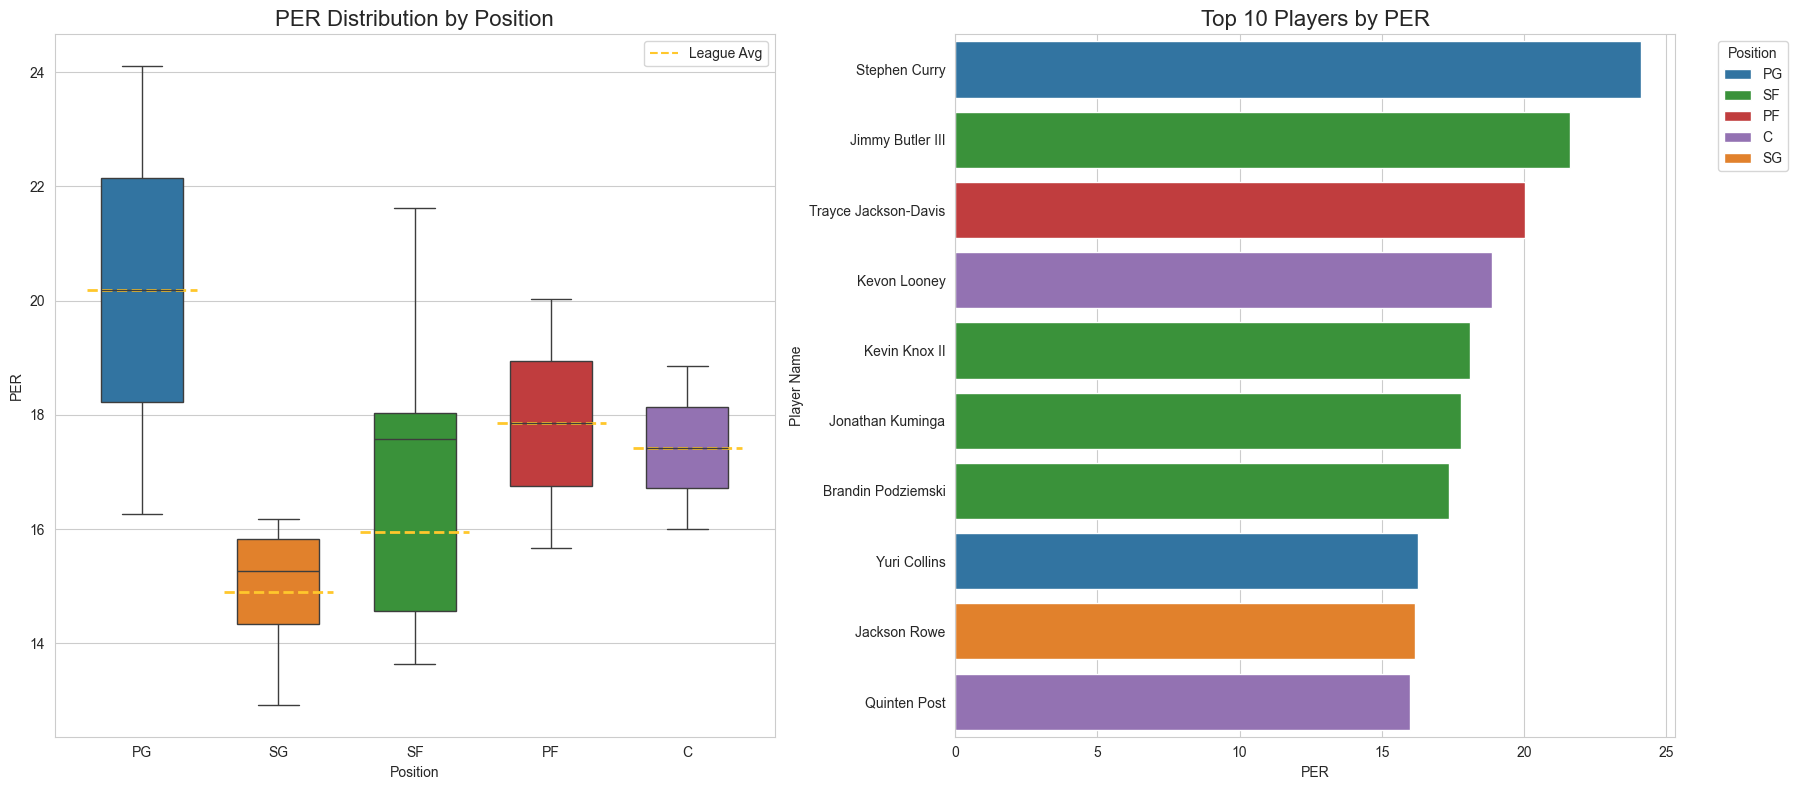

In [56]:
# 1. 라이브러리 임포트
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 2. 스타일 설정
sns.set_style('whitegrid')  # 흰 배경 + 그리드
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
sns.despine(left=False, bottom=False)

# 3. CSV 파일로 GSW PER 데이터 불러오기
csv_path = "C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_PER.csv"
df = pd.read_csv(csv_path)

# 4. 결측치 제거 (PER 또는 POSITION이 없는 행 제거)
df.dropna(subset=['PER', 'POSITION'], inplace=True)

# 5. 이상치 탐지 및 제거 — SF 제외, 나머지 포지션만 IQR 방식
outliers = []
for pos, group in df.groupby('POSITION'):
    if pos == 'SF':
        # SF는 이상치 제거 안 함
        continue
    Q1 = group['PER'].quantile(0.25)
    Q3 = group['PER'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    offs = group[(group['PER'] < lower) | (group['PER'] > upper)][['PLAYER_NAME','POSITION','PER']]
    outliers.append(offs)

# outliers_df 생성 (없으면 빈 DF)
outliers_df = pd.concat(outliers) if outliers else pd.DataFrame(columns=df.columns)
print("Detected Outliers (PER):")
print(outliers_df.to_string(index=False))

# 이상치 제거 적용 (SF 제외)
df = df[~df['PLAYER_NAME'].isin(outliers_df['PLAYER_NAME'])]

# 6. 상위 10 선수 및 포지션별 평균 계산
top10 = df.sort_values('PER', ascending=False).head(10)
avg_pos = df.groupby('POSITION')['PER'].mean().reset_index()

# 7. 포지션별 색상 정의
pos_palette = {
    'PG': '#1f77b4',
    'SG': '#ff7f0e',
    'SF': '#2ca02c',
    'PF': '#d62728',
    'C':  '#9467bd'
}

# 8. 시각화 — 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')
fig.subplots_adjust(wspace=0.5)

# 8.1 박스플롯: 포지션별 PER 분포
sns.boxplot(
    x='POSITION', y='PER', data=df,
    order=['PG','SG','SF','PF','C'],
    palette=pos_palette, width=0.6,
    showfliers=False,  # 이상치 포인트 표시 안 함
    whis=1.5,
    ax=ax1
)
ax1.set_title('PER Distribution by Position', fontsize=16)
ax1.set_xlabel('Position')
ax1.set_ylabel('PER')

# 리그 평균선 오버레이
for i, tick in enumerate(ax1.get_xticklabels()):
    pos = tick.get_text()
    mean_val = avg_pos.loc[avg_pos['POSITION']==pos, 'PER'].values
    if len(mean_val):
        ax1.hlines(y=mean_val[0], xmin=i-0.4, xmax=i+0.4,
                   colors='#FFC72C', linestyles='--', linewidth=2)

# 평균선 레전드 추가
ax1.legend([Line2D([0],[0], color='#FFC72C', linestyle='--')], ['League Avg'], loc='upper right')

# 8.2 바플롯: 상위 10 선수 PER
sns.barplot(
    x='PER', y='PLAYER_NAME', data=top10,
    hue='POSITION', palette=pos_palette,
    dodge=False, errorbar=None,
    ax=ax2
)
ax2.set_title('Top 10 Players by PER', fontsize=16)
ax2.set_xlabel('PER')
ax2.set_ylabel('Player Name')

# 포지션 범례
ax2.legend(title='Position', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()


In [42]:
# 1. 라이브러리 임포트
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from nba_api.stats.endpoints import LeagueDashPlayerStats

# 2. 스타일 설정
sns.set_style('whitegrid')
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
sns.despine(left=False, bottom=False)

# 3. 리그 전체 평균 계산 (API 사용)
from nba_api.stats.endpoints import LeagueDashPlayerStats
from nba_api.stats.static import players as players_static

# (a) Advanced 지표로 리그 전체 PER 가져오기 via API
adv_stats = LeagueDashPlayerStats(
    season='2024-25', per_mode_detailed='PerGame', measure_type_detailed='Advanced'
)
adv_df = adv_stats.get_data_frames()[0][['PLAYER_ID', 'PER']]

# (b) Static player list로 포지션 매핑
all_players = players_static.get_players()
position_map = {p['id']: p.get('pos') for p in all_players}
adf = adv_df.copy()
adf['POSITION'] = adf['PLAYER_ID'].map(position_map)
# 결측치 제거
df_league = adf.dropna(subset=['PER','POSITION'])
# 포지션별 리그 평균 계산
avg_pos_league = df_league.groupby('POSITION')['PER'].mean().reset_index()

# 4. GSW 전용 데이터 불러오기 (CSV 사용) GSW 전용 데이터 불러오기 (CSV 사용). GSW 전용 데이터 불러오기 (CSV 사용) GSW 전용 데이터 불러오기 (CSV 사용) GSW 전용 데이터 불러오기 (CSV 사용) GSW 전용 데이터 불러오기 (CSV 사용) GSW 전용 데이터 불러오기 (CSV 사용)
gsw_csv = 'C:/Users/THKIM/Desktop/3-1 프로젝트/오픈데이터분석 프로젝트/gsw_2024_25_PER.csv'
data_gsw = pd.read_csv(gsw_csv)[['PLAYER_NAME','PER','POSITION']]
data_gsw.dropna(subset=['PER','POSITION'], inplace=True)

# 5. 상위 10 GSW 선수
top10_gsw = data_gsw.sort_values('PER', ascending=False).head(10)

# 6. 포지션별 색상 팔레트
pos_palette = {
    'PG': '#1f77b4',
    'SG': '#ff7f0e',
    'SF': '#2ca02c',
    'PF': '#d62728',
    'C':  '#9467bd'
}

# 7. 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white'); ax2.set_facecolor('white')
fig.subplots_adjust(wspace=0.5)

# 7.1 GSW 박스플롯 + 리그 평균선
sns.boxplot(
    x='POSITION', y='PER', data=data_gsw,
    order=['PG','SG','SF','PF','C'],
    palette=pos_palette, width=0.6,
    showfliers=False, whis=1.5,
    ax=ax1
)
ax1.set_title('GSW PER Distribution by Position', fontsize=16)
ax1.set_xlabel('Position'); ax1.set_ylabel('PER')
# 리그 평균선 오버레이
league_means = avg_pos_league.set_index('POSITION')['PER']
for i, tick in enumerate(ax1.get_xticklabels()):
    pos = tick.get_text()
    if pos in league_means:
        ax1.hlines(y=league_means[pos], xmin=i-0.4, xmax=i+0.4,
                   colors='#FFC72C', linestyles='--', linewidth=2)
# 평균선 레전드
ax1.legend([Line2D([0],[0], color='#FFC72C', linestyle='--')], ['League Avg'], loc='upper right')

# 7.2 GSW Top 10 Barplot
sns.barplot(
    x='PER', y='PLAYER_NAME', data=top10_gsw,
    hue='POSITION', palette=pos_palette,
    dodge=False, errorbar=None,
    ax=ax2
)
ax2.set_title('Top 10 GSW Players by PER', fontsize=16)
ax2.set_xlabel('PER'); ax2.set_ylabel('Player Name')
ax2.legend(title='Position', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()


TypeError: LeagueDashPlayerStats.__init__() got an unexpected keyword argument 'measure_type_detailed'

<Figure size 640x480 with 0 Axes>

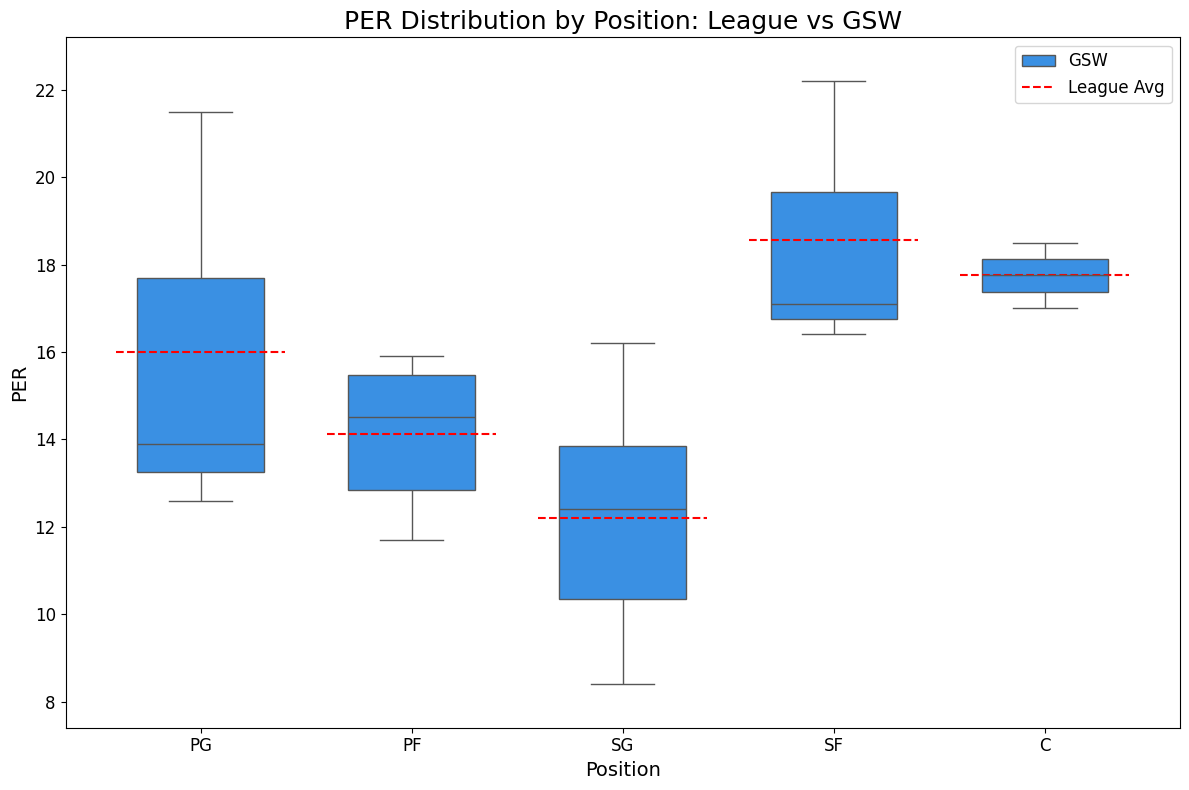

In [4]:
# 6. 시각화 — 박스플롯으로 리그 vs GSW 비교 & 리그 평균 오버레이
plt.figure(figsize=(12, 8))
ax = sns.boxplot(
    x='POSITION',
    y='PER',
    hue='Type',
    data=df,
    palette={'League':'#A9A9A9', 'GSW':'#1E90FF'},
    width=0.6
)
# 리그 평균 PER 수평선 오버레이
league_means = avg_per_position.set_index('POSITION')['PER']
for i, label in enumerate(ax.get_xticklabels()):
    pos = label.get_text()
    if pos in league_means.index:
        ax.hlines(y=league_means[pos], xmin=i-0.4, xmax=i+0.4,
                  colors='red', linestyles='--', linewidth=1.5)

plt.title('PER Distribution by Position: League vs GSW', fontsize=18)
plt.xlabel('Position', fontsize=14)
plt.ylabel('PER', fontsize=14)
plt.ylim(df['PER'].min() - 1, df['PER'].max() + 1)
# 범례 재설정
handles, labels = ax.get_legend_handles_labels()
# 빨간 선 레이블 추가
handles.append(plt.Line2D([], [], color='red', linestyle='--', linewidth=1.5))
labels.append('League Avg')
plt.legend(handles=handles, labels=labels, title='', fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


In [6]:

# 5. 상위10, 포지션별 평균 계산
top10 = df[['PLAYER_NAME','PER']].sort_values('PER', ascending=False).head(10)
avg_pos = df.groupby('POSITION')['PER'].mean().reset_index()


In [8]:
from matplotlib.lines import Line2D


In [13]:
# PER 컬럼
per_col = next((c for c in df.columns if c.strip().upper() == 'PER'), None)
if per_col is None:
    raise KeyError(f"PER 컬럼을 찾을 수 없습니다: {df.columns.tolist()}")
df.rename(columns={per_col: 'PER'}, inplace=True)
# POSITION 컬럼
pos_col = next((c for c in df.columns if c.strip().upper() in ['POSITION','POS']), None)
if pos_col is None:
    raise KeyError(f"POSITION 컬럼을 찾을 수 없습니다: {df.columns.tolist()}")
df.rename(columns={pos_col: 'POSITION'}, inplace=True)
# Type 컬럼
if 'Type' not in df.columns:
    df['Type'] = 'GSW'

# 5. 상위10, 포지션별 평균 계산
top10 = df[['PLAYER_NAME','PER','POSITION']].sort_values('PER', ascending=False).head(10)
avg_pos = df.groupby('POSITION')['PER'].mean().reset_index()

C:\Users\USER\AppData\Local\Temp\ipykernel_9912\838738315.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


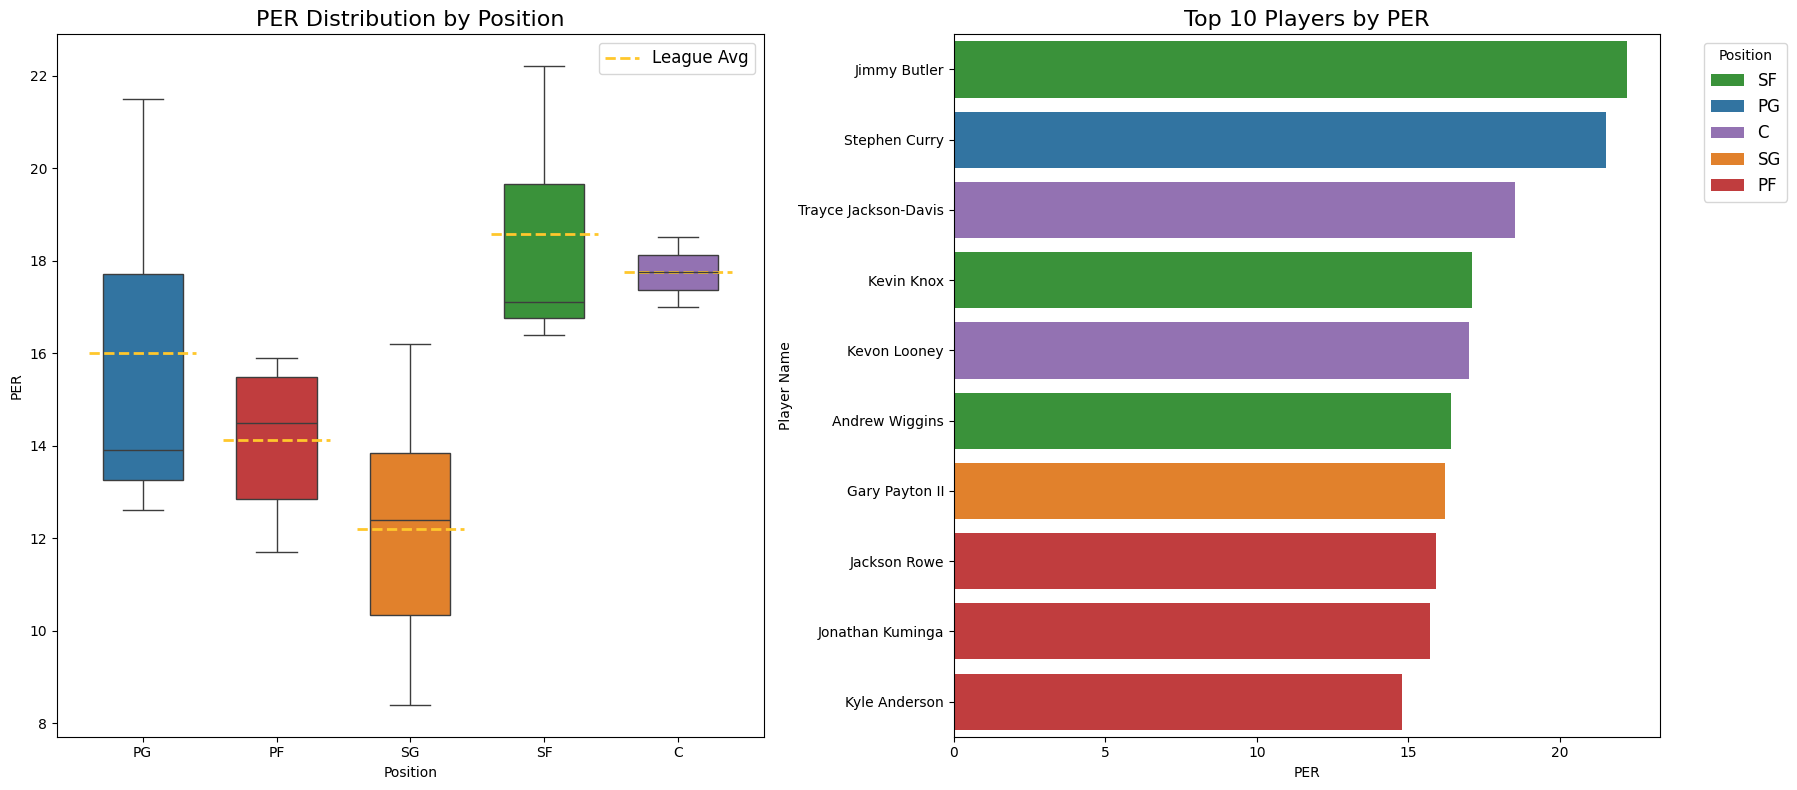

In [18]:
# 6. 시각화 — 서브플롯 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')
fig.subplots_adjust(wspace=0.5)

# 6.1 박스플롯 & 리그 평균 오버레이
# hue 대신 포지션별 색상을 사용해 통일
sns.boxplot(
    x='POSITION', y='PER', data=df,
    palette=pos_palette, width=0.6,
    ax=ax1
)
ax1.set_title('PER Distribution by Position', fontsize=16)
ax1.set_xlabel('Position')
ax1.set_ylabel('PER')
# 박스 안 검정 실선은 중앙값(Median)을 나타냅니다.
# 리그 평균선 오버레이
means = avg_pos.set_index('POSITION')['PER']
for i, tick in enumerate(ax1.get_xticklabels()):
    pos = tick.get_text()
    if pos in means:
        ax1.hlines(y=means[pos], xmin=i-0.4, xmax=i+0.4,
                   colors='#FFC72C', linestyles='--', linewidth=2)
# 박스플롯에서는 포지션 레전드를 제거하고 League Avg만 표시
league_line = Line2D([0],[0], color='#FFC72C', linestyle='--', linewidth=2)
ax1.legend(handles=[league_line], labels=['League Avg'], loc='upper right', fontsize=12)

# 6.2 선수별 PER Barplot (포지션별 색상, hue 사용) 선수별 PER Barplot (포지션별 색상, hue 사용) 선수별 PER Barplot (포지션별 색상, hue 사용) 선수별 PER Barplot (포지션별 색상, hue 사용)
# seaborn 최신 문법으로 palette 적용: hue='POSITION', errorbar=None
sns.barplot(
    x='PER',
    y='PLAYER_NAME',
    data=top10,
    hue='POSITION',
    palette=pos_palette,
    dodge=False,
    errorbar=None,
    ax=ax2
)
ax2.set_title('Top 10 Players by PER', fontsize=16)
ax2.set_xlabel('PER')
ax2.set_ylabel('Player Name')
# 포지션 범례 위치 조정
ax2.legend(title='Position', fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
plt.show()
